In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [6]:
#!pip install gdown
#import gdown

#url = "https://drive.google.com/uc?id=1uVX-I9ljmEwyd_q4iEzSNd3e4Qqa9i2w"
#gdown.download(url, "tccs_tratado.csv", quiet=False)

In [7]:
df = pd.read_csv('tccs_tratado.csv', delimiter=';')
df.head()

,titulo,nome_autor,nome_orientador,curso,nivel,tipo_trabalho,ano,data_defesa
0,múltipla filiação registral: análise constituc...,lorena nogueira rêgo,erica vericia canuto de oliveira veras,direito,graduação,monografia,2015.0,5015/11/25 00:00:00.000
1,o impacto da lei de responsabilidade fiscal so...,juliana cristina werneck,zivanilson teixeira e silva,ciências econômicas,graduação,monografia,2013.0,3013/12/17 00:00:00.000
2,avaliação do programa agroamigo dos território...,kalby andson eloi leite,zivanilson teixeira e silva,ciências econômicas,graduação,monografia,2013.0,3013/12/17 00:00:00.000
3,a exigibilidade da vacinação como medida profi...,diego alberto farias dantas,diogo pignataro de oliveira,direito,graduação,monografia,2022.0,2202/12/21 00:00:00.000
4,percepção sobre logística reversa da comunidad...,leandro medeiros dantas,larissa caroline saraiva ferreira,engenharia ambiental,graduação,monografia,2018.0,2201/12/04 00:00:00.000


In [8]:
cursos_unicos = df["curso"].dropna().unique()

print(f"Total de cursos: {len(cursos_unicos)}")
print(sorted(cursos_unicos))


Total de cursos: 485
['administração', 'administração pública', 'análise e desenvolvimento de sistemas', 'aperfeiçoamento em didática e método multissensorial no ensino a estudantes com deficiência visual', 'aperfeiçoamento em educação especial-inclusiva na educação básica', 'aperfeiçoamento em planejamento, criação e manutenção de repositórios digitais', 'aquicultura', 'arquitetura e urbanismo', 'artes visuais', 'bacharelado interdisciplinar em humanidades', 'biblioteconomia', 'biomedicina', 'ciência da computação', 'ciências atuariais', 'ciências biológicas', 'ciências contábeis', 'ciências e tecnologia', 'ciências econômicas', 'ciências sociais', 'comunicação social', 'comunicação social - audiovisual', 'comunicação social- publicidade e propaganda', 'curso de  especialização em administração pública', 'curso de especialização em análises clínicas', 'curso de especialização em auditoria e controle interno', 'curso de especialização em auditoria e perícia contábil', 'curso de especia

In [10]:
df = pd.read_csv("tccs_tratado.csv", sep=None, engine="python")

df_grad = df[df["nivel"].str.lower().str.contains("graduação", na=False)].copy()

df_grad["ano"] = pd.to_numeric(df_grad["ano"], errors="coerce").astype("Int64")
df_grad = df_grad[(df_grad["ano"] >= 2010) & (df_grad["ano"] <= 2025)]

tccs_por_ano = df_grad["ano"].value_counts().sort_index()

top_cursos = df_grad["curso"].value_counts().head(10).index

df_top_cursos = df_grad[df_grad["curso"].isin(top_cursos)]

evolucao_cursos = df_top_cursos.groupby(["ano", "curso"]).size().unstack(fill_value=0)

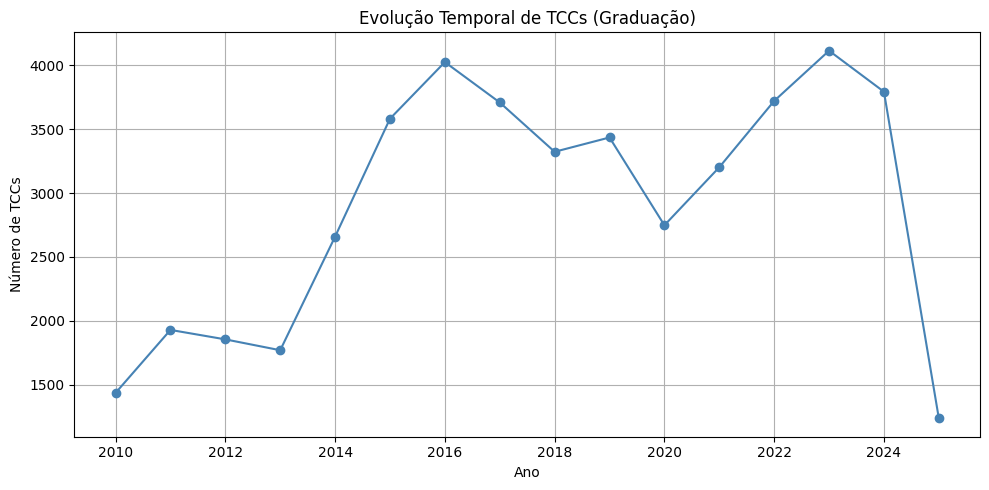

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(tccs_por_ano.index, tccs_por_ano.values, marker="o", color="steelblue")
plt.title("Evolução Temporal de TCCs (Graduação)")
plt.xlabel("Ano")
plt.ylabel("Número de TCCs")
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

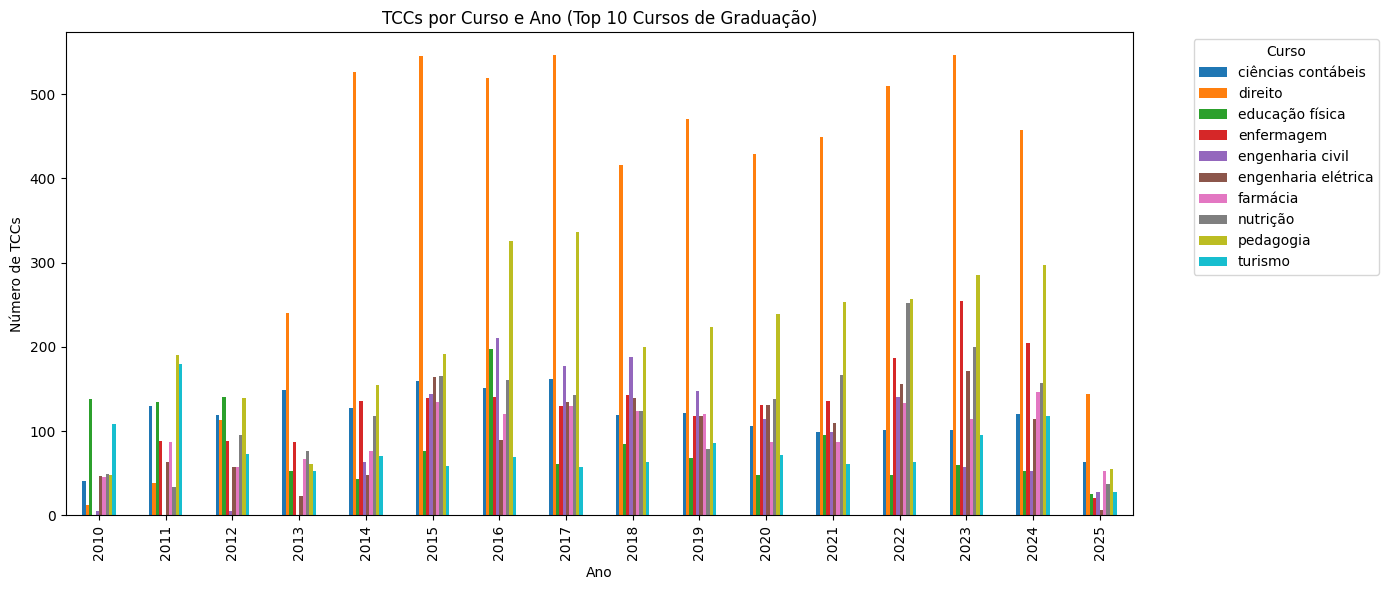

In [12]:
plt.figure(figsize=(14, 6))
evolucao_cursos.plot(kind='bar', stacked=False, figsize=(14,6))
plt.title("TCCs por Curso e Ano (Top 10 Cursos de Graduação)")
plt.xlabel("Ano")
plt.ylabel("Número de TCCs")
plt.legend(title="Curso", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


C:\Users\pedro\AppData\Local\Temp\ipykernel_5292\835041489.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tend_df['tendencia'], y=tend_df.index, palette="crest")


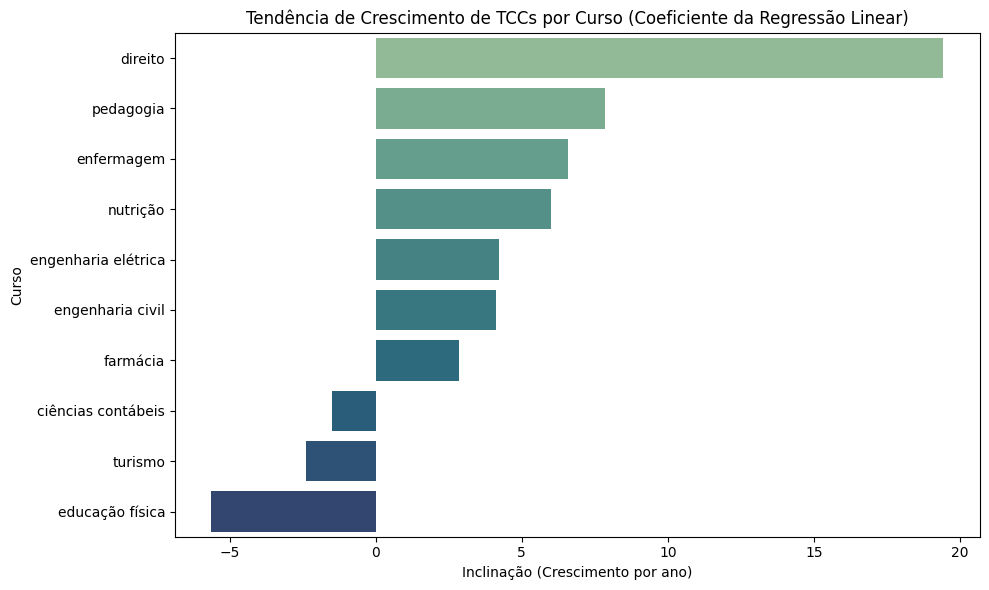

In [13]:
tendencias = {}

for curso in evolucao_cursos.columns:
    x = evolucao_cursos.index.values.reshape(-1, 1)
    y = evolucao_cursos[curso].values
    model = LinearRegression().fit(x, y)
    slope = model.coef_[0]
    tendencias[curso] = slope

tend_df = pd.DataFrame.from_dict(tendencias, orient='index', columns=['tendencia']).sort_values('tendencia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=tend_df['tendencia'], y=tend_df.index, palette="crest")
plt.title("Tendência de Crescimento de TCCs por Curso (Coeficiente da Regressão Linear)")
plt.xlabel("Inclinação (Crescimento por ano)")
plt.ylabel("Curso")
plt.tight_layout()
plt.show()

In [14]:
# RESULTADOS RESUMIDOS
print("TCCs por ano (últimos 5 anos):")
print(tccs_por_ano.tail())

print("\n Cursos com maior tendência de crescimento:")
print(tend_df.head())

print("\n Cursos com tendência de queda:")
print(tend_df.tail())

TCCs por ano (últimos 5 anos):
ano
2021    3202
2022    3721
2023    4114
2024    3793
2025    1237
Name: count, dtype: Int64

 Cursos com maior tendência de crescimento:
                     tendencia
direito              19.425000
pedagogia             7.860294
enfermagem            6.567647
nutrição              5.994118
engenharia elétrica   4.219118

 Cursos com tendência de queda:
                    tendencia
engenharia civil     4.105882
farmácia             2.842647
ciências contábeis  -1.477941
turismo             -2.398529
educação física     -5.616176


In [16]:
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.corpus import stopwords
import re
import unicodedata

In [17]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pedro\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [18]:
df_grad = df[df["nivel"].str.lower().str.contains("graduação", na=False)].copy()
df_grad["ano"] = pd.to_numeric(df_grad["ano"], errors="coerce").astype("Int64")
df_grad = df_grad[df_grad["ano"] >= 2010]

In [20]:
def limpar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = texto.lower()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8", "ignore")
    texto = re.sub(r"[^a-z\s]", " ", texto)
    return texto

df_grad["titulo_limpo"] = df_grad["titulo"].apply(limpar_texto)

stopwords_pt = set(stopwords.words("portuguese"))
def remover_stopwords(texto):
    return " ".join([t for t in texto.split() if t not in stopwords_pt and len(t) > 2])

df_grad["titulo_limpo"] = df_grad["titulo_limpo"].apply(remover_stopwords)

todas_palavras = " ".join(df_grad["titulo_limpo"]).split()
contador = Counter(todas_palavras)
top_20 = contador.most_common(20)

C:\Users\pedro\AppData\Local\Temp\ipykernel_5292\670206345.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(frequencias), y=list(palavras), palette="viridis")


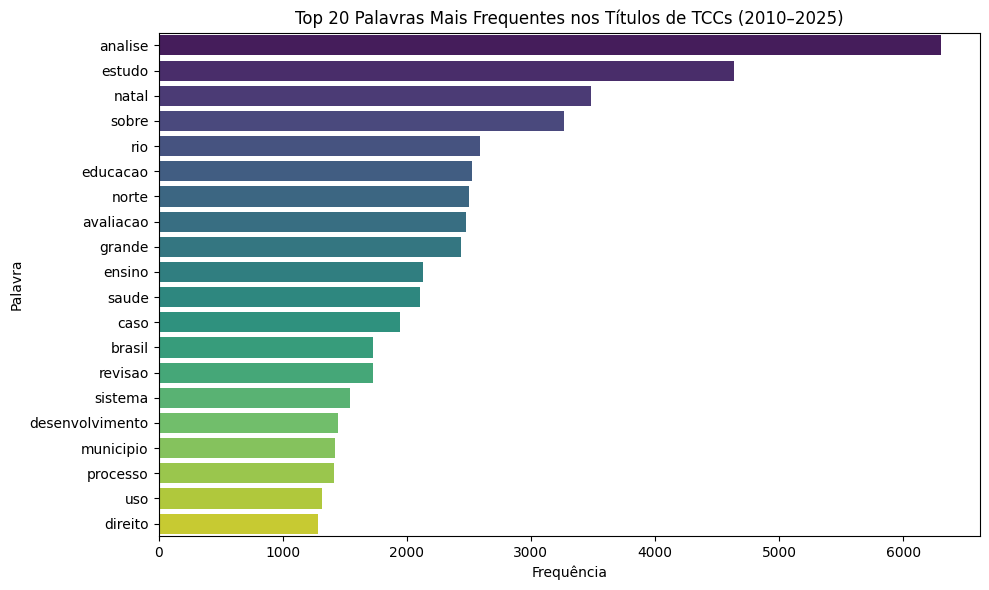

In [21]:
palavras, frequencias = zip(*top_20)
plt.figure(figsize=(10,6))
sns.barplot(x=list(frequencias), y=list(palavras), palette="viridis")
plt.title("Top 20 Palavras Mais Frequentes nos Títulos de TCCs (2010–2025)")
plt.xlabel("Frequência")
plt.ylabel("Palavra")
plt.tight_layout()
plt.show()

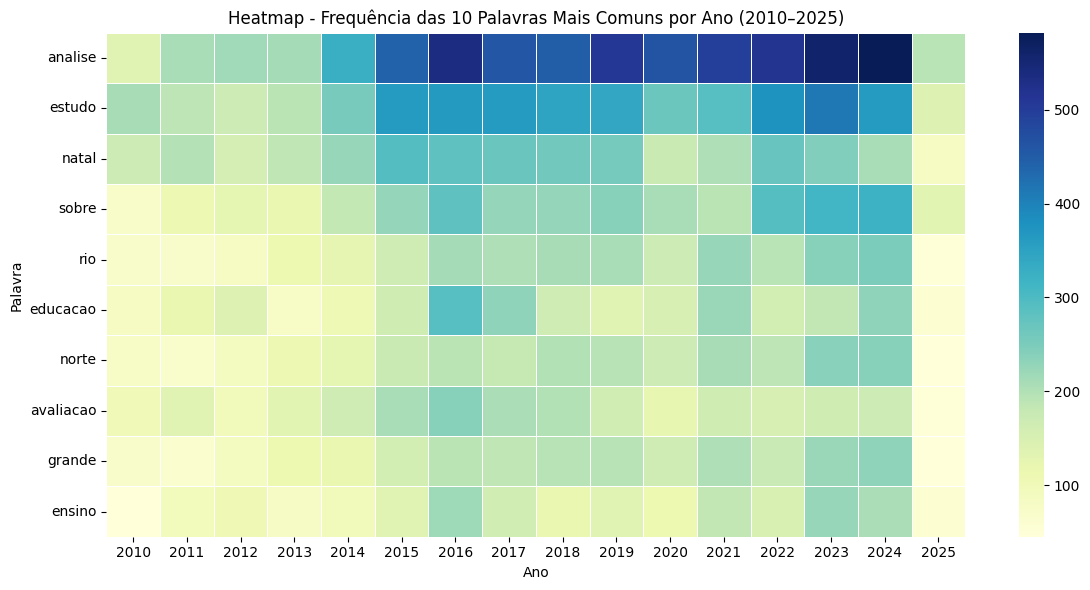

In [22]:
principais_termos = [p for p, _ in top_20[:10]]
linhas = []

for _, linha in df_grad.iterrows():
    ano = linha["ano"]
    palavras = linha["titulo_limpo"].split()
    for palavra in palavras:
        if palavra in principais_termos:
            linhas.append({"ano": ano, "palavra": palavra})

df_freq_tempo = pd.DataFrame(linhas).groupby(["ano", "palavra"]).size().unstack(fill_value=0)

plt.figure(figsize=(12,6))
sns.heatmap(df_freq_tempo[principais_termos].T, cmap="YlGnBu", linewidths=0.5)
plt.title("Heatmap - Frequência das 10 Palavras Mais Comuns por Ano (2010–2025)")
plt.xlabel("Ano")
plt.ylabel("Palavra")
plt.tight_layout()
plt.show()


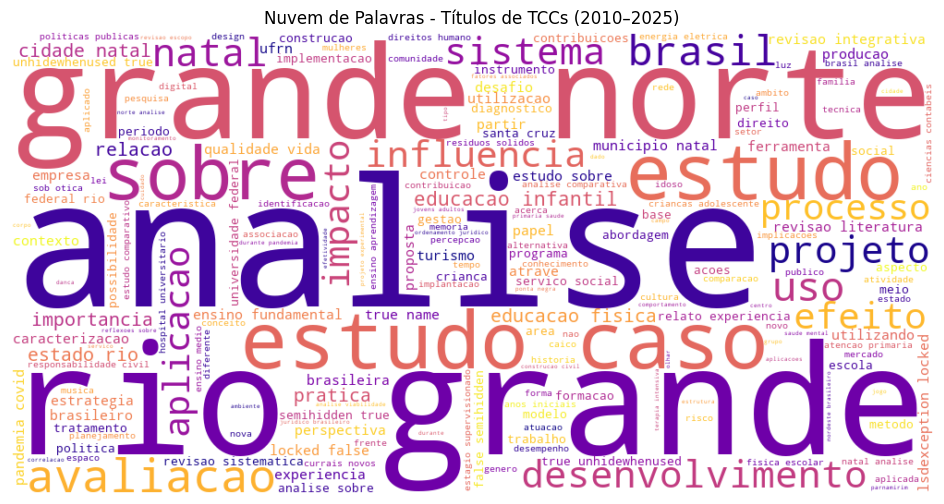

In [23]:
texto_geral = " ".join(df_grad["titulo_limpo"])
wordcloud = WordCloud(width=1000, height=500, background_color="white", colormap="plasma").generate(texto_geral)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de Palavras - Títulos de TCCs (2010–2025)")
plt.show()

In [ ]:
df_pos2010 = df_grad[df_grad["ano"] >= 2010].copy()

linhas = []
for _, linha in df_pos2010.iterrows():
    curso = linha["curso"]
    palavras = linha["titulo_limpo"].split()
    for palavra in palavras:
        linhas.append({"curso": curso, "palavra": palavra})

df_palavras_curso = pd.DataFrame(linhas)

top_palavras_curso = (
    df_palavras_curso.groupby(["curso", "palavra"]).size()
    .reset_index(name="frequencia")
)

top5_por_curso = (
    top_palavras_curso.sort_values(["curso", "frequencia"], ascending=[True, False])
    .groupby("curso")
    .head(5)
)

top5_por_curso.head(50)


,curso,palavra,frequencia
818,administração,estudo,268
332,administração,caso,189
110,administração,analise,153
976,administração,gestao,119
2044,administração,trabalho,81
2295,administração pública,gestao,15
2299,administração pública,grande,15
2347,administração pública,norte,15
2405,administração pública,rio,15
2185,administração pública,analise,13


/tmp/ipython-input-2138369979.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_orientadores.values, y=top_orientadores.index, palette="mako")


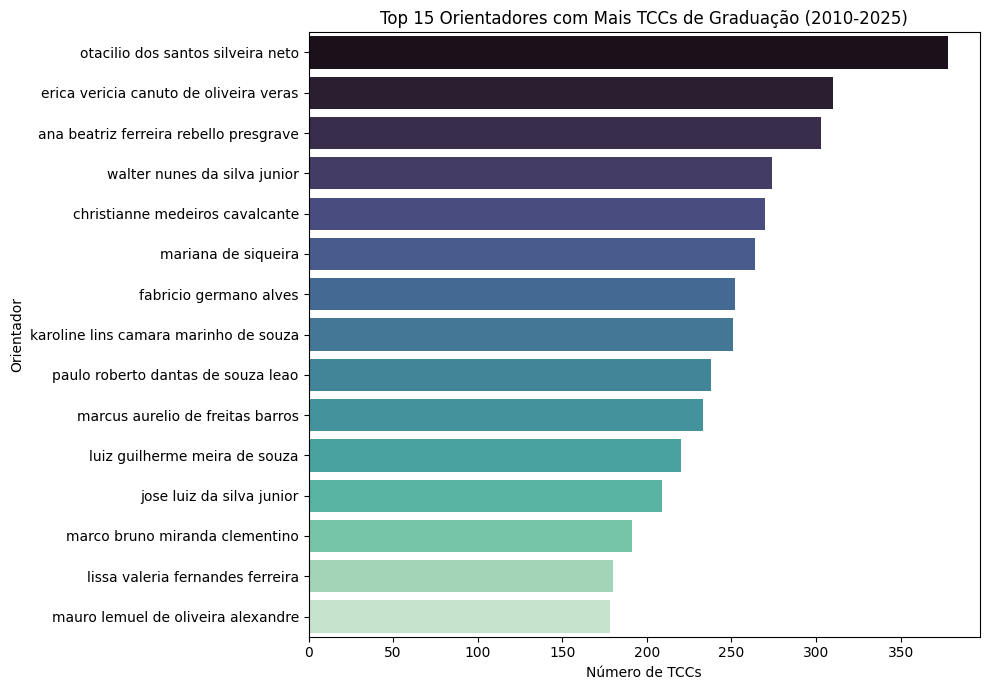

In [ ]:
top_orientadores = df_grad['nome_orientador'].value_counts().head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_orientadores.values, y=top_orientadores.index, palette="mako")
plt.title('Top 15 Orientadores com Mais TCCs de Graduação (2010-2025)')
plt.xlabel('Número de TCCs')
plt.ylabel('Orientador')
plt.tight_layout()
plt.show()

In [ ]:
top_orientadores_curso = (
    df_top_cursos.groupby('curso')['nome_orientador']
    .value_counts()
    .groupby(level=0)
    .head(3)
)

print(top_orientadores_curso)

curso                nome_orientador                                   
ciências contábeis   daniele da rocha carvalho                              97
                     mauricio correa da silva                               94
                     socrates dantas lopes                                  79
direito              otacilio dos santos silveira neto                     378
                     erica vericia canuto de oliveira veras                310
                     ana beatriz ferreira rebello presgrave                303
educação física      paulo moreira silva dantas                            136
                     elizabeth jatoba bezerra tinoco                        93
                     maria aparecida dias                                   92
enfermagem           quenia camille soares martins                          92
                     luiz alves morais filho                                82
                     maria leonor paiva da silva           

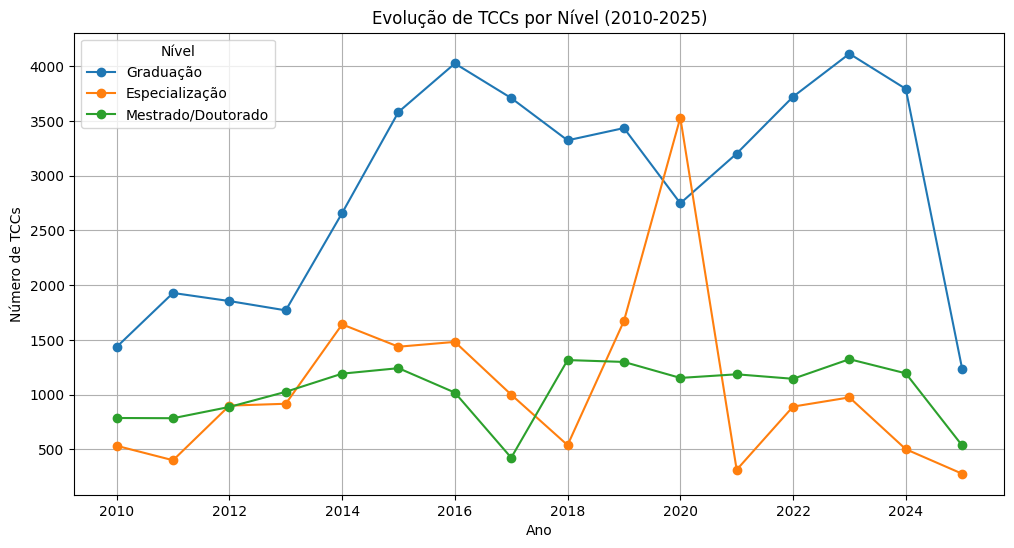

In [ ]:
df_niveis = df[df['ano'] >= 2010].copy()

df_niveis['nivel_limpo'] = df_niveis['nivel'].str.lower().fillna('outro')
df_niveis['categoria_nivel'] = 'Outro'

df_niveis.loc[df_niveis['nivel_limpo'].str.contains('graduação'), 'categoria_nivel'] = 'Graduação'
df_niveis.loc[df_niveis['nivel_limpo'].str.contains('lato sensu|especialização'), 'categoria_nivel'] = 'Especialização'
df_niveis.loc[df_niveis['nivel_limpo'].str.contains('stricto sensu|mestrado|doutorado'), 'categoria_nivel'] = 'Mestrado/Doutorado'

evolucao_niveis = df_niveis.groupby('ano')['categoria_nivel'].value_counts().unstack(fill_value=0)

evolucao_niveis = evolucao_niveis[['Graduação', 'Especialização', 'Mestrado/Doutorado']]

evolucao_niveis.plot(kind='line', figsize=(12, 6), marker='o')
plt.title('Evolução de TCCs por Nível (2010-2025)')
plt.xlabel('Ano')
plt.ylabel('Número de TCCs')
plt.grid(True)
plt.legend(title='Nível')
plt.show()

In [ ]:
df_direito = df_grad[df_grad['curso'] == 'direito']
df_pedagogia = df_grad[df_grad['curso'] == 'pedagogia']

texto_direito = " ".join(df_direito['titulo_limpo'])
contador_direito = Counter(texto_direito.split())
top_direito = contador_direito.most_common(15)

texto_pedagogia = " ".join(df_pedagogia['titulo_limpo'])
contador_pedagogia = Counter(texto_pedagogia.split())
top_pedagogia = contador_pedagogia.most_common(15)

print("--- Top 15 Palavras em Direito ---")
print(pd.DataFrame(top_direito, columns=['Palavra', 'Frequência']))
print("\n--- Top 15 Palavras em Pedagogia---")
print(pd.DataFrame(top_pedagogia, columns=['Palavra', 'Frequência']))

--- Top 15 Palavras em Direito ---
             Palavra  Frequência
0            analise        1412
1            direito        1183
2              sobre         528
3         brasileiro         496
4                luz         475
5                lei         449
6             brasil         447
7              penal         415
8              civil         408
9           direitos         401
10          trabalho         340
11          juridica         325
12          processo         323
13  responsabilidade         314
14          juridico         305

--- Top 15 Palavras em Pedagogia---
         Palavra  Frequência
0       educacao        1111
1         ensino         801
2       infantil         640
3         escola         419
4       formacao         346
5        escolar         339
6    fundamental         311
7   aprendizagem         300
8          sobre         289
9       processo         261
10       pratica         238
11      praticas         235
12      criancas       